# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Бісюк Роман Васильович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 1      # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 1 · Бісюк Роман Васильович, ШІ-34, «Астро-ТВ»
Підприємство «Астро-ТВ» виготовляє телевізори. Одиниця виміру плану: шт./день.

                       Astro  Cosmo  Nova  Vega  ЗАПАС
Конвеєр A, год             0      2     1     1    929
Конвеєр Б, год             3      3     0     6    410
Цех кінескопів, год        2      3     0     2    507
Цех корпусів, год          4      6     0     5    865
Ділянка збирання, год      3      1     5     4    425

                    Astro  Cosmo  Nova  Vega
Прибуток з одиниці     21     69    44    39

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Конвеєр Б, год
  ціна:   16.2 за одиницю
  обсяг:  до 44 одиниць


In [3]:
# Встановлення бібліотек для розв'язання задач лінійного програмування
%pip install "pulp==2.9.0" scipy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

**Змінні рішення:**

* `x1` — випуск телевізорів Astro, шт./день
* `x2` — випуск телевізорів Cosmo, шт./день
* `x3` — випуск телевізорів Nova, шт./день
* `x4` — випуск телевізорів Vega, шт./день

**Цільова функція** (прибуток за день, максимізуємо):

`Z = 21·x1 + 69·x2 + 44·x3 + 39·x4 → max`

**Обмеження** (витрати ресурсу не перевищують запас, год/день):

* `0·x1 + 2·x2 + 1·x3 + 1·x4 ≤ 929   (конвеєр A)`
* `3·x1 + 3·x2 + 0·x3 + 6·x4 ≤ 410   (конвеєр Б)`
* `2·x1 + 3·x2 + 0·x3 + 2·x4 ≤ 507   (цех кінескопів)`
* `4·x1 + 6·x2 + 0·x3 + 5·x4 ≤ 865   (цех корпусів)`
* `3·x1 + 1·x2 + 5·x3 + 4·x4 ≤ 425   (ділянка збирання)`

**Невід'ємність:**

`x1 ≥ 0,  x2 ≥ 0,  x3 ≥ 0,  x4 ≥ 0`

### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:**

Запас — параметр, бо підприємство його не обирає: він заданий заздалегідь.
Модель обирає лише випуск x1–x4.

Якби ресурс можна було докупити, обсяг закупівлі `y` став би змінною рішення:
обмеження `... ≤ 410 + y`, а з прибутку віднімалося б `ціна·y`.

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [5]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [0, 136.6667, 57.6667, 0]
EXCEL_ПРИБУТОК = 11967.33           

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 136.6667, 57.6667, 0] | прибуток 11967.33


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [6]:
# ВАШ КОД
r = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None)] * 4, method='highs')

план = r.x
прибуток = -r.fun

print('Статус:', r.message)
print('План:', dict(zip(вироби, np.round(план, 3))))
print('Прибуток:', round(прибуток, 2))

Статус: Optimization terminated successfully. (HiGHS Status 7: Optimal)
План: {'Astro': np.float64(0.0), 'Cosmo': np.float64(136.667), 'Nova': np.float64(57.667), 'Vega': np.float64(0.0)}
Прибуток: 11967.33


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [7]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Конвеєр A | 331 | 0 | 929 | 1E+30 | 598 |
| Конвеєр Б | 410 | 20,067 | 410 | 22,5 | 410 |
| Цех кінескопів | 410 | 0 | 507 | 1E+30 | 97 |
| Цех корпусів | 820 | 0 | 865 | 1E+30 | 45 |
| Ділянка збирання | 425 | 8,8 | 425 | 2990 | 288,33 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**

Дефіцит: конвеєр Б і ділянка збирання — кінцеве значення дорівнює запасу, тіньова ціна > 0.
Надлишок: конвеєр A, цех кінескопів, цех корпусів — є залишок, тіньова ціна 0.

### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Astro | 0 | −65,6 | 21 | 65,6 | 1E+30 |
| Cosmo | 136,667 | 0 | 69 | 1E+30 | 58,3 |
| Nova | 57,667 | 0 | 44 | 301 | 44 |
| Vega | 0 | −116,6 | 39 | 116,6 | 1E+30 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.** Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план? Звідки ви взяли це число?

Не виробляються Astro і Vega. Прибуток з одиниці мав би зрости: Astro — на 65,6 (до 86,6), Vega — на 116,6 (до 155,6).
Число взято зі стовпця «Зведена вартість» (за модулем), воно ж — «Допустиме збільшення».

---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [8]:
# ВАШ КОД
тіньові = -r.ineqlin.marginals          # тіньові ціни з Python
і = int(np.argmax(тіньові))             # найдорожчий ресурс
print('Найдорожчий ресурс:', ресурси[і], '| тіньова ціна', round(тіньові[і], 4))

b2 = b.copy()
b2[і] += 1                               # +1 година
r2 = linprog(-c, A_ub=A, b_ub=b2, bounds=[(0, None)] * 4, method='highs')

приріст = -r2.fun - прибуток
print('Новий прибуток:', round(-r2.fun, 2))
print('Приріст:', round(приріст, 4))

Найдорожчий ресурс: Конвеєр Б, год | тіньова ціна 20.0667
Новий прибуток: 11987.4
Приріст: 20.0667


**Відповідь 5.1:** приріст прибутку = 20,067, тіньова ціна зі звіту = 20,067 — збігаються.

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

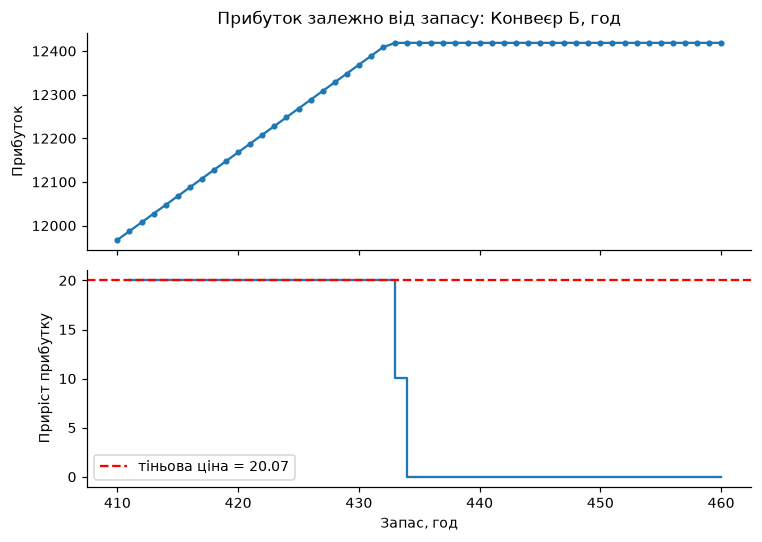

Тіньова ціна діє до запасу ≈ 432.0 | збільшення на 22.0


In [9]:
# ВАШ КОД
запаси = np.arange(b[і], b[і] + 51)      # 410, 411, ..., 460
прибутки = []
for q in запаси:
    b2 = b.copy()
    b2[і] = q
    r2 = linprog(-c, A_ub=A, b_ub=b2, bounds=[(0, None)] * 4, method='highs')
    прибутки.append(-r2.fun)

прирости = np.diff(прибутки)             # приріст на кожну +1 годину

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7, 5))
ax1.plot(запаси, прибутки, marker='.')
ax1.set_ylabel('Прибуток')
ax1.set_title('Прибуток залежно від запасу: ' + ресурси[і])

ax2.step(запаси[1:], прирости, where='post')
ax2.axhline(тіньові[і], color='red', ls='--', label='тіньова ціна = %.2f' % тіньові[і])
ax2.set_xlabel('Запас, год')
ax2.set_ylabel('Приріст прибутку')
ax2.legend()
plt.tight_layout()
plt.show()

межа = запаси[1:][np.where(np.abs(прирости - тіньові[і]) > 1e-6)[0][0]] - 1
print('Тіньова ціна діє до запасу ≈', межа, '| збільшення на', межа - b[і])

**Відповідь 5.2:** запас конвеєра Б можна збільшити на 22,5 год (до ≈432,5), і весь цей час
кожна година дає +20,067 — це тіньова ціна. Далі приріст падає до 0, бо закінчується
вільний час цеху корпусів. Експеримент дав +22 (крок 1 не бачить половинки),
тобто збігається з «допустимим збільшенням» 22,5 зі звіту Excel.

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [10]:
# ВАШ КОД
k      = V['ресурс_пропозиції']       # який ресурс пропонують (конвеєр Б)
ціна   = V['ціна_пропозиції']         # 16.2 за годину
обсяг  = V['обсяг_пропозиції']        # до 44 годин
тінь   = тіньові[k]                   # 20.067
межа_звіту = 22.5                     # «допустиме збільшення» зі звіту Excel

print('Ресурс:', ресурси[k], '| ціна', ціна, '| тіньова ціна', round(тінь, 3))

купити = min(обсяг, межа_звіту)       # більше не має сенсу
виграш_оцінка = купити * (тінь - ціна)
print('Купити:', купити, 'год | очікуваний виграш:', round(виграш_оцінка, 2))

def чистий_виграш(q):
    b2 = b.copy()
    b2[k] += q
    r2 = linprog(-c, A_ub=A, b_ub=b2, bounds=[(0, None)] * 4, method='highs')
    return (-r2.fun - прибуток) - q * ціна

print('Перевірка, купити', купити, 'год:', round(чистий_виграш(купити), 2))
print('Для порівняння, купити всі', обсяг, 'год:', round(чистий_виграш(обсяг), 2))

Ресурс: Конвеєр Б, год | ціна 16.2 | тіньова ціна 20.067
Купити: 22.5 год | очікуваний виграш: 87.0
Перевірка, купити 22.5 год: 87.0
Для порівняння, купити всі 44 год: -261.3


**Відповідь 6.1:**

* Брати чи ні і чому: брати — ціна 16,2 менша за тіньову ціну 20,067,
  кожна година дає ≈3,87 чистого прибутку.
* Скільки одиниць має сенс купити і чому не більше: 22,5 год (якщо тільки цілі — 22).
  Це «допустиме збільшення» зі звіту: після нього тіньова ціна падає до 0,
  і зайві години були б викинутими грошима.
* Очікуваний виграш: 22,5 · (20,067 − 16,2) = 87,0.
* Перевірка прямим розв'язанням дала: 87,0 — збігається.
  Якби купили всі 44 год, був би збиток 261,3.

---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [11]:
# ВАШ КОД
залишки = b - A @ план                        # скільки кожного ресурсу лишилося

ненульових = int((план > 1e-6).sum())          # вироби з випуском > 0
звязних = int((np.abs(залишки) < 1e-6).sum())  # ресурси, витрачені повністю

print('Ненульові вироби:', [в for в, x in zip(вироби, план) if x > 1e-6])
print('Зв’язні ресурси:', [р for р, s in zip(ресурси, залишки) if abs(s) < 1e-6])

Ненульові вироби: ['Cosmo', 'Nova']
Зв’язні ресурси: ['Конвеєр Б, год', 'Ділянка збирання, год']


In [12]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** числа збіглися: 2 ненульові вироби (Cosmo, Nova) і 2 зв'язні
обмеження (конвеєр Б, ділянка збирання). Це нормальний, невироджений розв'язок.
Якби зв'язних обмежень було більше, ніж ненульових виробів (виродження),
тіньові ціни були б неоднозначні, і на звіт про стійкість не можна було б
повністю покладатися. Розбіжність також може означати помилку в моделі.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [13]:
# ВАШ КОД
# 1. Без умови цілочисельності (вже маємо)
print('1) Дробовий:', np.round(план, 3), '| прибуток', round(прибуток, 2))

# 2. Округлений план
округл = np.round(план)
перевищення = A @ округл - b                 # > 0 означає, що ресурсу не вистачає
допустимий = bool(np.all(перевищення <= 1e-6))
print('2) Округлений:', округл, '| прибуток', c @ округл, '| допустимий:', допустимий)
for р, s in zip(ресурси, перевищення):
    if s > 1e-6:
        print('   не вистачає:', р, 'на', s)

# 3. Справжній цілочисельний оптимум
r_int = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None)] * 4,
                method='highs', integrality=1)
print('3) Цілочисельний:', np.round(r_int.x), '| прибуток', round(-r_int.fun, 2))


1) Дробовий: [  0.    136.667  57.667   0.   ] | прибуток 11967.33
2) Округлений: [  0. 137.  58.   0.] | прибуток 12005.0 | допустимий: False
   не вистачає: Конвеєр Б, год на 1.0
   не вистачає: Ділянка збирання, год на 2.0
3) Цілочисельний: [  0. 136.  57.  -0.] | прибуток 11892.0


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | 0; 136,667; 57,667; 0 | 11 967,33 | так |
| округлений | 0; 137; 58; 0 | 12 005 | ні — не вистачає 1 год конвеєра Б і 2 год збирання |
| цілочисельний оптимум | 0; 136; 57; 0 | 11 892 | так |

**Висновок:** просто округлювати не можна: округлений план виходить за межі ресурсів,
а його «вищий» прибуток нездійсненний. Правильно розв'язувати задачу з умовою
цілочисельності. Тут цілий оптимум лише на 75 менший за дробовий.

---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [14]:
# ВАШ КОД — впишіть свої дані
постачальники = ['Біла Церква', 'Івано-Франківськ', 'Суми']
споживачі     = ['Рівне', 'Одеса', 'Миколаїв', 'Ахтирка']

D = np.array([
    # Рівне  Одеса  Миколаїв  Ахтирка
    [   360,     393,      401,        458],   # Біла Церква
    [   275,     798,      806,        986],   # Івано-Франківськ
    [   659,     804,      607,        78],   # Суми
])                                     # км, Google Maps

запас = [35, 28, 22]                   # сума 85
попит = [17, 24, 19, 25]               # сума 85

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Рівне,Одеса,Миколаїв,Ахтирка
Біла Церква,360,393,401,458
Івано-Франківськ,275,798,806,986
Суми,659,804,607,78


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [15]:
m, n = 3, 4
p = pulp.LpProblem('transport', pulp.LpMinimize)
x = {(i, j): pulp.LpVariable(f'x_{i}_{j}', lowBound=0) for i in range(m) for j in range(n)}

p += pulp.lpSum(D[i, j] * x[i, j] for i in range(m) for j in range(n))      # вартість, км
for i in range(m):
    p += pulp.lpSum(x[i, j] for j in range(n)) == запас[i], f'пост_{i}'     # вивезти весь запас
for j in range(n):
    p += pulp.lpSum(x[i, j] for i in range(m)) == попит[j], f'спож_{j}'     # задовольнити попит

p.solve(pulp.PULP_CBC_CMD(msg=0))

план1 = np.array([[x[i, j].value() for j in range(n)] for i in range(m)])
вартість1 = pulp.value(p.objective)
тіні1 = np.array([p.constraints[k].pi for k in p.constraints])

print('pulp: вартість', вартість1)
display(pd.DataFrame(план1, index=постачальники, columns=споживачі))
print('Тіньові ціни (3 постачальники, 4 споживачі):', тіні1)

pulp: вартість 29271.0


,Рівне,Одеса,Миколаїв,Ахтирка
Біла Церква,0.0,13.0,19.0,3.0
Івано-Франківськ,17.0,11.0,0.0,0.0
Суми,0.0,0.0,0.0,22.0


Тіньові ціни (3 постачальники, 4 споживачі): [ 393.  798.   13. -523.    0.    8.   65.]


In [16]:
A_eq, b_eq = [], []
for i in range(m):                    # рядок i: сума перевезень з постачальника i
    row = np.zeros((m, n)); row[i, :] = 1
    A_eq.append(row.flatten()); b_eq.append(запас[i])
for j in range(n):                    # стовпець j: сума перевезень до споживача j
    row = np.zeros((m, n)); row[:, j] = 1
    A_eq.append(row.flatten()); b_eq.append(попит[j])

r_t = linprog(D.flatten(), A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')

план2 = r_t.x.reshape(m, n)
вартість2 = r_t.fun
тіні2 = r_t.eqlin.marginals

print('linprog: вартість', вартість2)
display(pd.DataFrame(план2, index=постачальники, columns=споживачі))
print('Тіньові ціни (3 постачальники, 4 споживачі):', тіні2)

linprog: вартість 29271.0


,Рівне,Одеса,Миколаїв,Ахтирка
Біла Церква,0.0,24.0,8.0,3.0
Івано-Франківськ,17.0,0.0,11.0,0.0
Суми,0.0,0.0,0.0,22.0


Тіньові ціни (3 постачальники, 4 споживачі): [  -0.  405. -380. -130.  393.  401.  458.]


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [22]:
# ВАШ КОД — порівняння
різниця = тіні1 - тіні2
print('Вартість:', вартість1, 'vs', вартість2)
print('Різниця, постачальники:', різниця[:3])
print('Різниця, споживачі:   ', різниця[3:])

Вартість: 29271.0 vs 29271.0
Різниця, постачальники: [393. 393. 393.]
Різниця, споживачі:    [-393. -393. -393. -393.]


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: однакова, 29 271.
* Тіньові ціни збіглися чи ні: ні.
* Яку закономірність ви побачили в різниці: у всіх постачальників різниця однакова (+393),
  у всіх споживачів — така сама з протилежним знаком (−393). Причина: одне з 7 обмежень
  зайве (сума запасів = сумі попиту), тому тіньові ціни визначені лише з точністю до сталої.
  Обидві відповіді правильні.
* Що це означає для того, хто ухвалює рішення: окрему тіньову ціну тут читати не можна,
  сенс має лише сума «постачальник + споживач». Змінити запас одного постачальника
  окремо не можна: порушиться баланс.

---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [24]:
план = план2                                    # план з linprog (з pulp вийде те саме число)

ненульових_т = int((план > 1e-6).sum())

залишки_пост = np.array(запас) - план.sum(axis=1)   # скільки не вивезено
залишки_спож = np.array(попит) - план.sum(axis=0)   # скільки не довезено
звязних_т = int((np.abs(залишки_пост) < 1e-6).sum() + (np.abs(залишки_спож) < 1e-6).sum())

print('Ненульових перевезень:', ненульових_т)
print('Зв’язних обмежень:', звязних_т, 'з', m + n)
print('m + n − 1 =', m + n - 1)

Ненульових перевезень: 6
Зв’язних обмежень: 7 з 7
m + n − 1 = 6


**Відповідь 11.1:**

* Ненульових перевезень: 6
* Зв'язних обмежень: 7
* Чому зв'язні всі: обмеження — рівності, тобто весь запас вивозиться і весь попит
  задовольняється завжди, за самою постановкою.
* На скільки менше і чому: на 1, бо одне обмеження зайве (сума запасів = сумі попиту).
  Незалежних обмежень 3 + 4 − 1 = 6, тому і ненульових перевезень 6.
  Перевірка «ненульові = зв'язні» з етапу 7 тут не працює.

### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

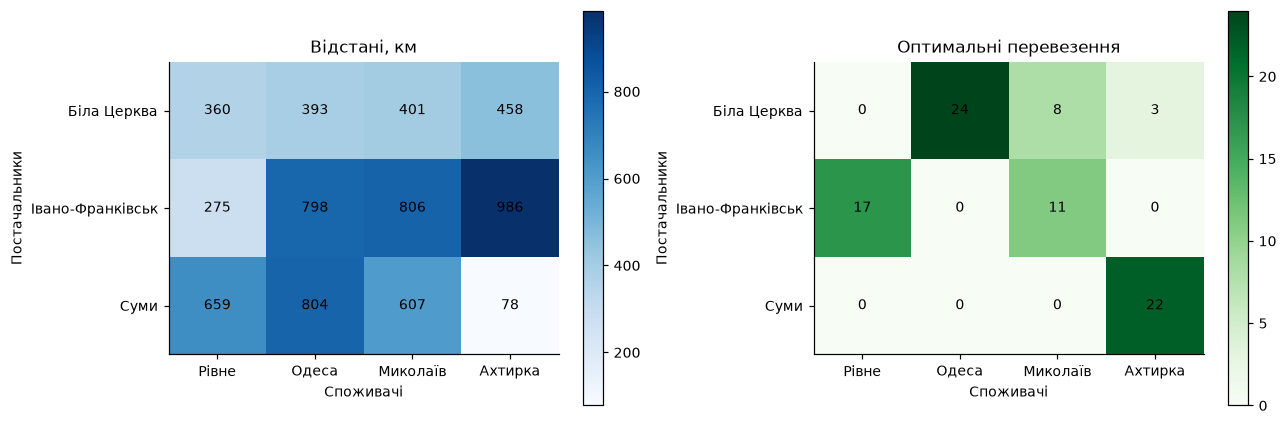

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, M, назва, cmap in [(axes[0], D, 'Відстані, км', 'Blues'),
                           (axes[1], план, 'Оптимальні перевезення', 'Greens')]:
    im = ax.imshow(M, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_xticklabels(споживачі)
    ax.set_yticks(range(m)); ax.set_yticklabels(постачальники)
    ax.set_xlabel('Споживачі'); ax.set_ylabel('Постачальники')
    ax.set_title(назва)
    for i in range(m):
        for j in range(n):
            ax.text(j, i, '%g' % M[i, j], ha='center', va='center')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

**Висновок:** перевезення йдуть переважно короткими маршрутами: Суми везуть усе
в Ахтирку (78 км), Івано-Франківськ — у Рівне (275 км), Біла Церква забезпечує південь.
Найдовші маршрути (800–986 км) не використовуються; лише 11 од. з Івано-Франківська
до Миколаєва вимушені, бо запасу Білої Церкви на весь південь не вистачає.

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [32]:
ІНСТРУМЕНТИ_ШІ = 'Claude'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'текст, перероблено',
    'етап 2, побудова моделі в Excel':      'код, перевірено',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

ЩО_ПЕРЕВІРЕНО = ('План і прибуток у Python збіглися з Excel (11967,33). Знайшов і виправив '
                 'помилку у формулах Excel (цільова клітинка рахувала не той рядок). '
                 'Перевірив, що +1 год конвеєра Б дає приріст 20,067 = тіньовій ціні, а межа '
                 'на графіку ≈22,5 збігається з допустимим збільшенням. Перевірив недопустимість '
                 'округленого плану. У транспортній задачі переконався, що вартість у pulp і '
                 'linprog однакова, а тіньові ціни відрізняються на сталу ±393.')

ПІДТВЕРДЖУЮ = True

In [33]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Бісюк Роман Васильович
інструменти:                               Claude
------------------------------------------------------------------------------
етап 1, формалізація моделі:               текст, перероблено
етап 2, побудова моделі в Excel:           код, перевірено
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             код, перевірено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
План і прибуток у Python збіглися з Excel (11967,33). Знайшов і виправив помилку у формулах Excel (цільова клітинка рахувала не той рядок). Перевірив, що +1 год конвеєра Б дає приріст 20,067 = тіньовій ціні, а межа на графіку ≈22,5 збігається з допустимим збільшення

---
# Крок 13. Фінальна самоперевірка

In [34]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
